# EC9630 Machine Learning - Laboratory 2

# Name : Gajanayaka P.A.G.T.M.L.

# Reg No : 2021/E/119

# Date : 2025/02/21

# Time : 1.30 PM


#**CSV FIle**

In [5]:
import pandas as pd
import numpy as np
from google.colab import drive
from google.colab import files

#Load the dataset
drive.mount('/content/drive')
df = pd.read_csv("/content/hour.csv")

print("Dataset Information:")
print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16

# **Preprocessing Data**

In [6]:
from sklearn.model_selection import train_test_split

# Drop the column
df.drop(["instant", "dteday", "casual", "registered"], axis=1, inplace=True)
df.dropna(inplace=True)

# Encoding categorical variables
df = pd.get_dummies(df, columns=["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"], drop_first=True)

# Splitting data into features and target variable
X = df.drop("cnt", axis=1)
y = df["cnt"]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13903, 53), (3476, 53), (13903,), (3476,))

*   80% of the data is used for training (X_train, y_train).

*   20% of the data is used for testing (X_test, y_test).

#**linear regression model**

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Compute error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 74.10515899029578
Mean Squared Error: 10089.38811515939
Root Mean Squared Error: 100.44594623557185



*   Mean Absolute Error **(MAE)**: Measures the average absolute difference between actual and predicted values.

*   Mean Squared Error **(MSE)**: Penalizes larger errors more by squaring them.

*   Root Mean Squared Error **(RMSE)**: The square root of MSE, keeping it in the same unit as the target variable.

*   These metrics help assess how well the model generalizes to unseen data.

##**actual target value vs predicted value**

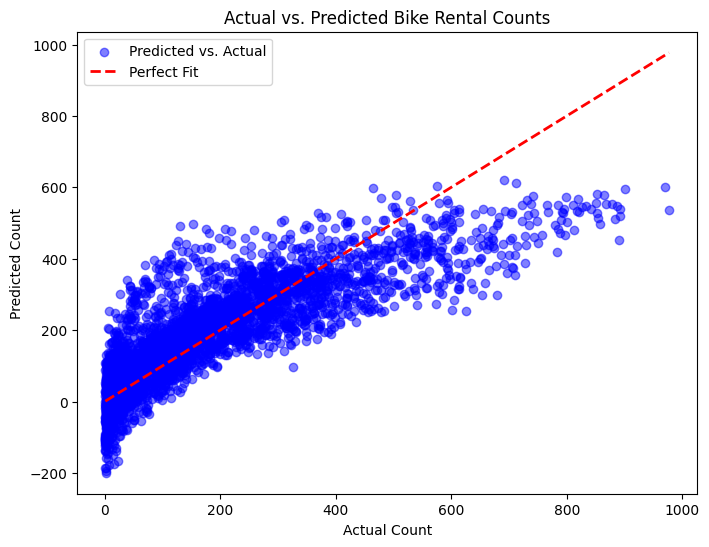

In [8]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted Bike Rental Counts")
plt.legend()
plt.show()

# **Analyze Impact of Regularization**

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

ridge_model = Ridge(alpha=2.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=.01)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.01)

# **Compare coefficients from the unregularized and regularized models.**

In [10]:
print("\nCoefficients Comparison with Ridge:")
print("Linear Regression Coefficients:\n",model.coef_)
print("Ridge Regression Coefficients:\n", ridge_model.coef_)

print("\nCoefficients Comparison with lasso:")
print("Linear Regression Coefficients:\n",model.coef_)
print("Lasso Regression Coefficients:\n", lasso_model.coef_)


Coefficients Comparison with Ridge:
Linear Regression Coefficients:
 [ 1.12791420e+02  1.23382685e+02 -8.18851908e+01 -3.09635713e+01
  3.38639342e+01  3.03611203e+01  6.83411300e+01  8.59838810e+01
  1.98281165e+00  1.47788847e+01  1.10748368e+01  2.40892845e+01
  1.22126834e+01 -8.48285125e+00  9.90478479e+00  3.67744804e+01
  1.65041346e+01 -1.15124715e+01 -7.66237056e+00 -1.68430512e+01
 -2.72189996e+01 -3.72714437e+01 -3.96841318e+01 -2.16668743e+01
  3.50478173e+01  1.71989771e+02  3.16215410e+02  1.64222776e+02
  1.11261979e+02  1.33886716e+02  1.76513289e+02  1.72052240e+02
  1.50772507e+02  1.59877369e+02  2.25789337e+02  3.82737711e+02
  3.42536350e+02  2.35937957e+02  1.59765751e+02  1.09428129e+02
  7.20238780e+01  3.30292847e+01 -1.42391687e+01 -3.77288065e+00
 -2.15016146e+00 -6.09290770e-02 -5.82778098e-01  4.57959507e+00
  1.63742573e+01  1.22520145e+01 -1.11996807e+01 -6.45685889e+01
 -1.27627990e+02]
Ridge Regression Coefficients:
 [ 1.17090231e+02  1.20794255e+02 -8

# **Impact of Regularization on Model Performance**

In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train Ridge Regression (L2 regularization)
ridge_model = Ridge(alpha=1.0)  # Regularization strength = 1.0
ridge_model.fit(X_train, y_train)
y_ridge_pred = ridge_model.predict(X_test)

# Train Lasso Regression (L1 regularization)
lasso_model = Lasso(alpha=0.1)  # Regularization strength = 0.1
lasso_model.fit(X_train, y_train)
y_lasso_pred = lasso_model.predict(X_test)

# Compute error metrics for Ridge
mae_ridge = mean_absolute_error(y_test, y_ridge_pred)
mse_ridge = mean_squared_error(y_test, y_ridge_pred)
rmse_ridge = np.sqrt(mse_ridge)

# Compute error metrics for Lasso
mae_lasso = mean_absolute_error(y_test, y_lasso_pred)
mse_lasso = mean_squared_error(y_test, y_lasso_pred)
rmse_lasso = np.sqrt(mse_lasso)

print(f"Ridge MSE: {mse_ridge}")
print(f"Lasso MSE: {mse_lasso}")

# Compare results
print("Linear Regression:", (mae, mse, rmse))
print("Ridge Regression:", (mae_ridge, mse_ridge, rmse_ridge))
print("Lasso Regression:", (mae_lasso, mse_lasso, rmse_lasso))


Ridge MSE: 10083.461255154647
Lasso MSE: 10109.115426452863
Linear Regression: (74.10515899029578, 10089.38811515939, 100.44594623557185)
Ridge Regression: (74.08053666379024, 10083.461255154647, 100.41643916787055)
Lasso Regression: (74.00379014087602, 10109.115426452863, 100.54409692494563)


*   Ridge Regression (L2 Regularization): Penalizes large coefficients to reduce overfitting.

*   Lasso Regression (L1 Regularization): Can shrink some coefficients to zero, performing feature selection.


*   alpha controls the strength of regularization (higher alpha means stronger regularization).

*   Ridge regression prevents overfitting by shrinking coefficients.
Lasso regression eliminates some coefficients (useful for feature selection).

*   Comparing MSE and RMSE values, we analyze how regularization affects the model's accuracy.

*   If Ridge/Lasso reduces test error, it indicates overfitting in Linear Regression.

# **Retrieve coefficients from both models**

In [18]:
coefficients_lr = model.coef_
coefficients_ridge = ridge_model.coef_

coefficients_lr = model.coef_
coefficients_lasso = lasso_model.coef_

# **Create an index for each coefficient (for plotting purposes)**

In [19]:
indices = range(len(coefficients_lr))

# **Plot the coefficients of both models**

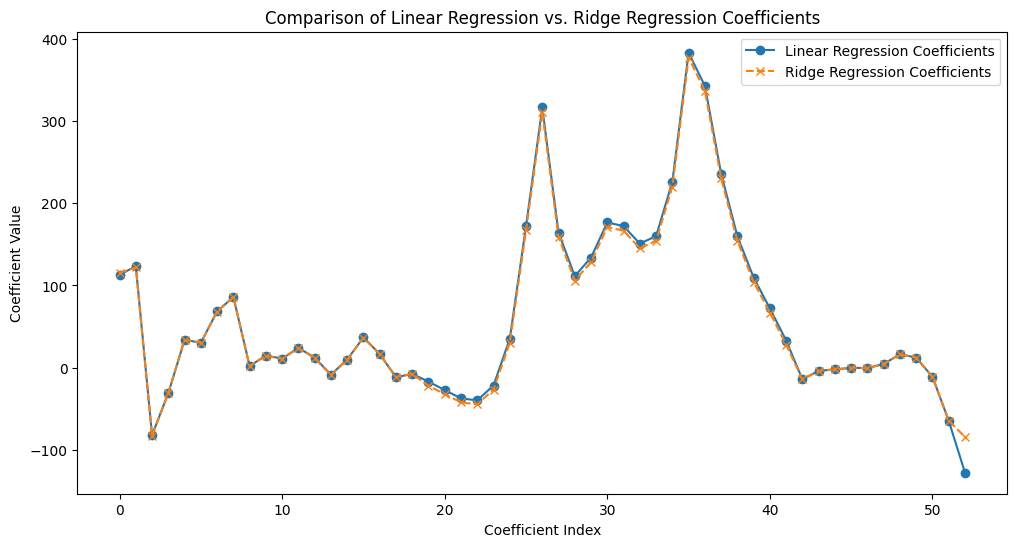

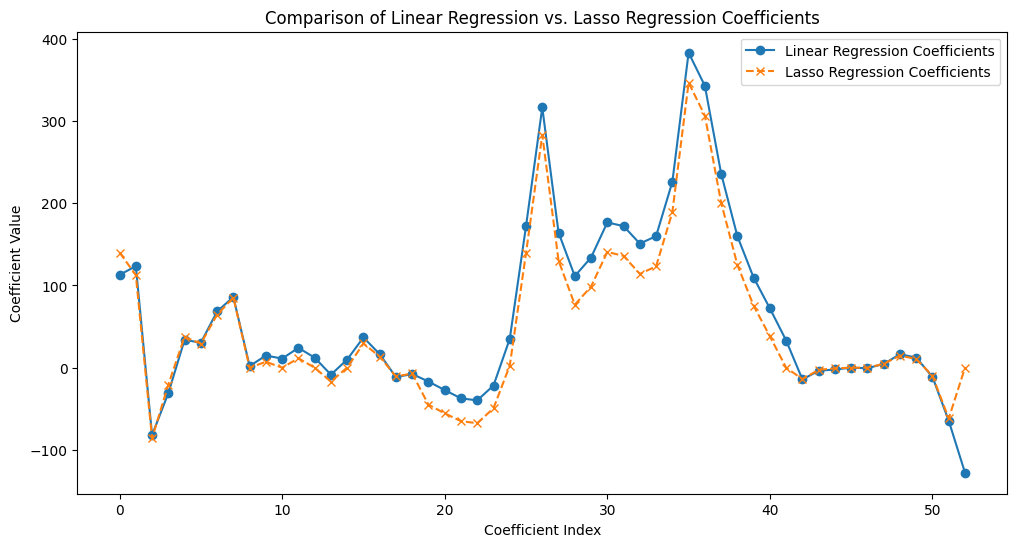

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(indices, coefficients_lr, marker='o', linestyle='-', label='Linear Regression Coefficients')
plt.plot(indices, coefficients_ridge, marker='x', linestyle='--', label='Ridge Regression Coefficients')
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Comparison of Linear Regression vs. Ridge Regression Coefficients")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(indices, coefficients_lr, marker='o', linestyle='-', label='Linear Regression Coefficients')
plt.plot(indices, coefficients_lasso, marker='x', linestyle='--', label='Lasso Regression Coefficients')
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Comparison of Linear Regression vs. Lasso Regression Coefficients")
plt.legend()
plt.show()

# **Plot the differences between the coefficients of the two models**

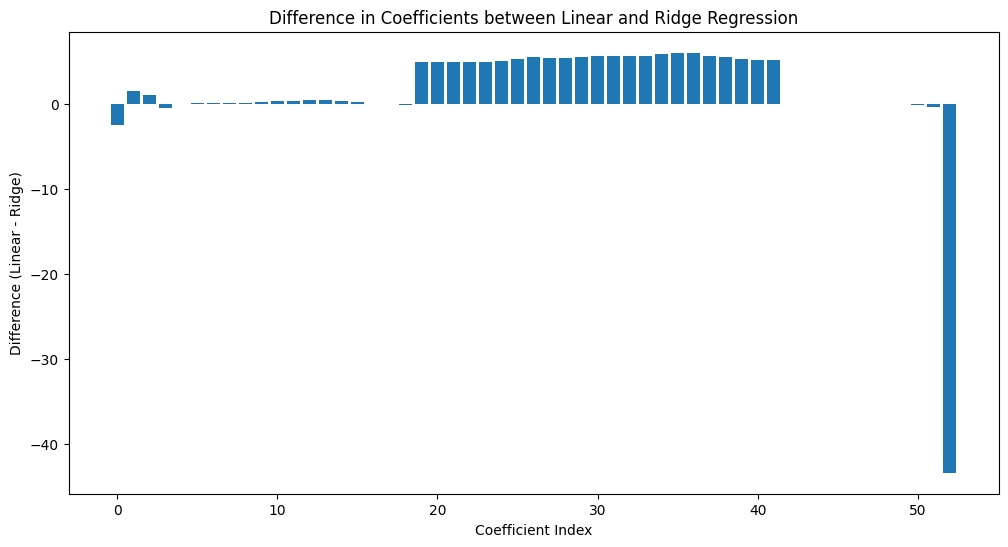

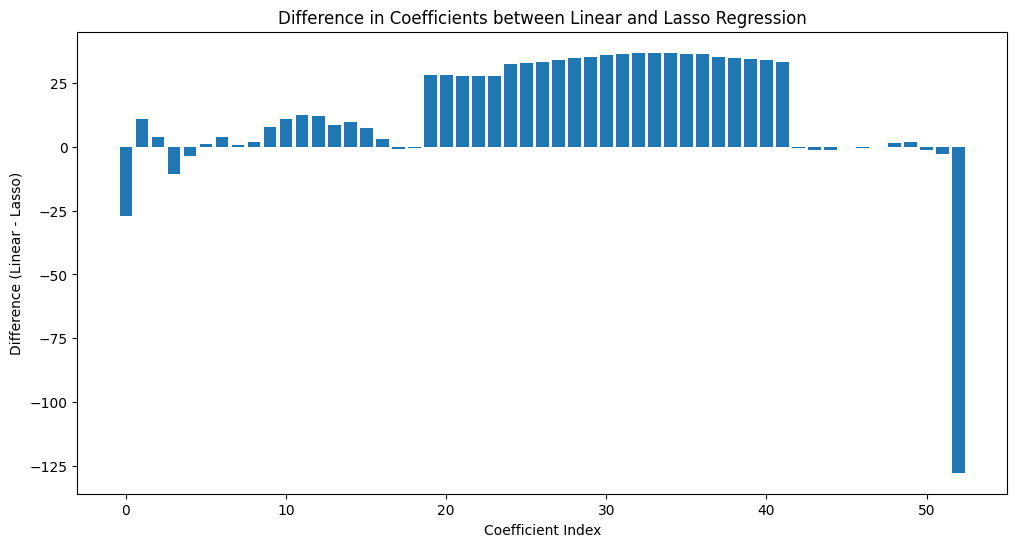

In [21]:
coeff_diff = coefficients_lr - coefficients_ridge
plt.figure(figsize=(12, 6))
plt.bar(indices, coeff_diff)
plt.xlabel("Coefficient Index")
plt.ylabel("Difference (Linear - Ridge)")
plt.title("Difference in Coefficients between Linear and Ridge Regression")
plt.show()

coeff_diff = coefficients_lr - coefficients_lasso
plt.figure(figsize=(12, 6))
plt.bar(indices, coeff_diff)
plt.xlabel("Coefficient Index")
plt.ylabel("Difference (Linear - Lasso)")
plt.title("Difference in Coefficients between Linear and Lasso Regression")
plt.show()

# **Saving and Exporting the Model**

In [22]:
import joblib

# Save trained model and download
joblib.dump(ridge_model, "Trained_model.pkl")
print("Trained model saved successfully!")
files.download("Trained_model.pkl")

Trained model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>